## Introduction
The analysis of Spotify songs, characterized by a rich set of features such as danceability, energy, and valence, holds significant importance in the realm of music research, entertainment, and data-driven decision-making. Understanding the musical attributes of songs through data analysis provides valuable insights into user preferences, genre trends, and the overall landscape of the music industry. This type of analysis contributes to personalized recommendations for users, enhancing their music discovery experience. Moreover, it aids music producers and artists in tailoring their creations to align with popular trends and audience preferences. Additionally, the exploration of Spotify song data has the potential to uncover patterns, correlations, and anomalies that can inform marketing strategies, playlist curation, and even influence the strategic planning of music events. Overall, the analysis of Spotify songs is instrumental in leveraging data to enhance user experiences, guide artistic endeavors, and inform strategic decisions within the dynamic and ever-evolving music industry.

## Requirements

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
pip install scikit-learn

## **The Spotify Songs Dataset**

## Downloading the Spotify Songs Dataset

In [ ]:
!gdown 1ayxWv-hlQdzGoHMnrtNWRae9YxlTFP-_

Downloading...
From: https://drive.google.com/uc?id=1ayxWv-hlQdzGoHMnrtNWRae9YxlTFP-_
To: /content/spotify-songs.csv
100% 1.82M/1.82M [00:00<00:00, 118MB/s]


## Exploring the Spotify Songs Dataset
The dataset consists of information on more than 30,000 songs obtained from the Spotify API, with various musical features and genres. The features include danceability, energy, loudness, speechiness, acousticness, instrumentalness, liveness, valence, tempo, and genre. Each feature provides insights into different aspects of the songs, such as danceability, intensity, loudness, presence of spoken words, acoustic nature, instrumental content, live performance likelihood, musical positiveness, tempo, and genre. All these features except 'genre' serve as input variables for potential analysis and modeling. The 'genre' attribute serves as the target variable, representing the song genre to be predicted. The dataset offers a comprehensive collection of attributes, making it suitable for exploring and understanding the musical characteristics of a diverse range of songs.

**Loading the dataset into a `pandas` data frame.**

In [ ]:
import pandas as pd
import missingno as msno
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder

In [40]:
# Write your code here. Add as many boxes as you need.
df=pd.read_csv('/content/drive/MyDrive/Python Projects/KNN Classification/spotify-songs.csv')
df=df.copy(deep=True)
df.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036,pop
1,0.726,NaN,-4.969,0.0373,0.0724,NaN,0.3570,0.693,99.972,pop
2,0.675,0.931,-3.432,0.0742,0.0794,NaN,0.1100,0.613,124.008,pop
3,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,NaN,pop
4,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976,pop


In [ ]:
df

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,genre
0,0.748,0.916,-2.634,0.0583,0.102000,0.000000,0.0653,0.5180,122.036,pop
1,0.726,NaN,-4.969,0.0373,0.072400,NaN,0.3570,0.6930,99.972,pop
2,0.675,0.931,-3.432,0.0742,0.079400,NaN,0.1100,0.6130,124.008,pop
3,0.718,0.930,-3.778,0.1020,0.028700,0.000009,0.2040,0.2770,NaN,pop
4,0.650,0.833,-4.672,0.0359,0.080300,0.000000,0.0833,0.7250,123.976,pop
...,...,...,...,...,...,...,...,...,...,...
32828,0.428,NaN,-1.814,0.0936,0.076600,0.000000,0.0668,0.2100,128.170,edm
32829,0.522,0.786,-4.462,0.0420,0.001710,0.004270,0.3750,0.4000,128.041,edm
32830,0.529,0.821,-4.899,0.0481,0.108000,NaN,0.1500,0.4360,127.989,edm
32831,0.626,NaN,NaN,0.1090,0.007920,0.127000,0.3430,0.3080,128.008,edm


-Encoding the target variable using the `LabelEncoder` from the `scikit-learn` library.

In [ ]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['genre']= le.fit_transform(df['genre'])

-Exploring the dataset using visualizations.

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
ds = df['genre'].value_counts()
ds

,count
genre,
0,6043
4,5746
2,5507
3,5431
1,5155
5,4951


<Axes: xlabel='genre'>

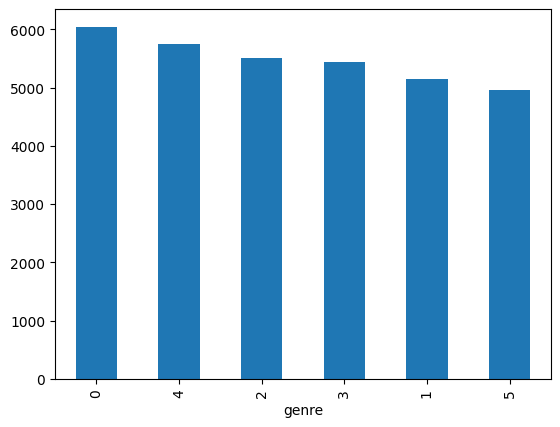

In [ ]:
ds.plot.bar()

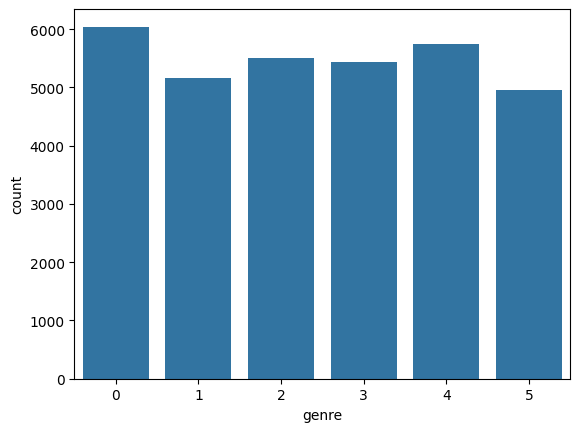

In [ ]:
sns.countplot(x='genre', data=df)
plt.show()

-Checking if the dataset is balanced.

In [ ]:
class_proportions = df['genre'].value_counts(normalize=True)
print(class_proportions)

genre
0    0.184053
4    0.175007
2    0.167728
3    0.165413
1    0.157007
5    0.150793
Name: proportion, dtype: float64


## Detecting Missing Values
-Calculating the percentage of missing values present in each column of the dataset.

In [ ]:
missing_values_df = df.isnull().sum()
percentage_df = 100 * df.isnull().sum() / len(df)
missing_values_table_df = pd.concat([missing_values_df, percentage_df], axis=1)
missing_values_table_df.columns = ['Num. of missing values','% of missing values']
missing_values_table_df

,Num. of missing values,% of missing values
danceability,3662,11.153413
energy,11261,34.297810
loudness,7620,23.208357
speechiness,2361,7.190936
acousticness,894,2.722870
instrumentalness,6470,19.705784
liveness,2986,9.094509
valence,7489,22.809369
tempo,6557,19.970761
genre,0,0.000000


## Visualization
-With tools such as heatmaps, dendrograms, matrices and bar charts with the `missingno` library.

In [ ]:
import missingno as msno

<Axes: >

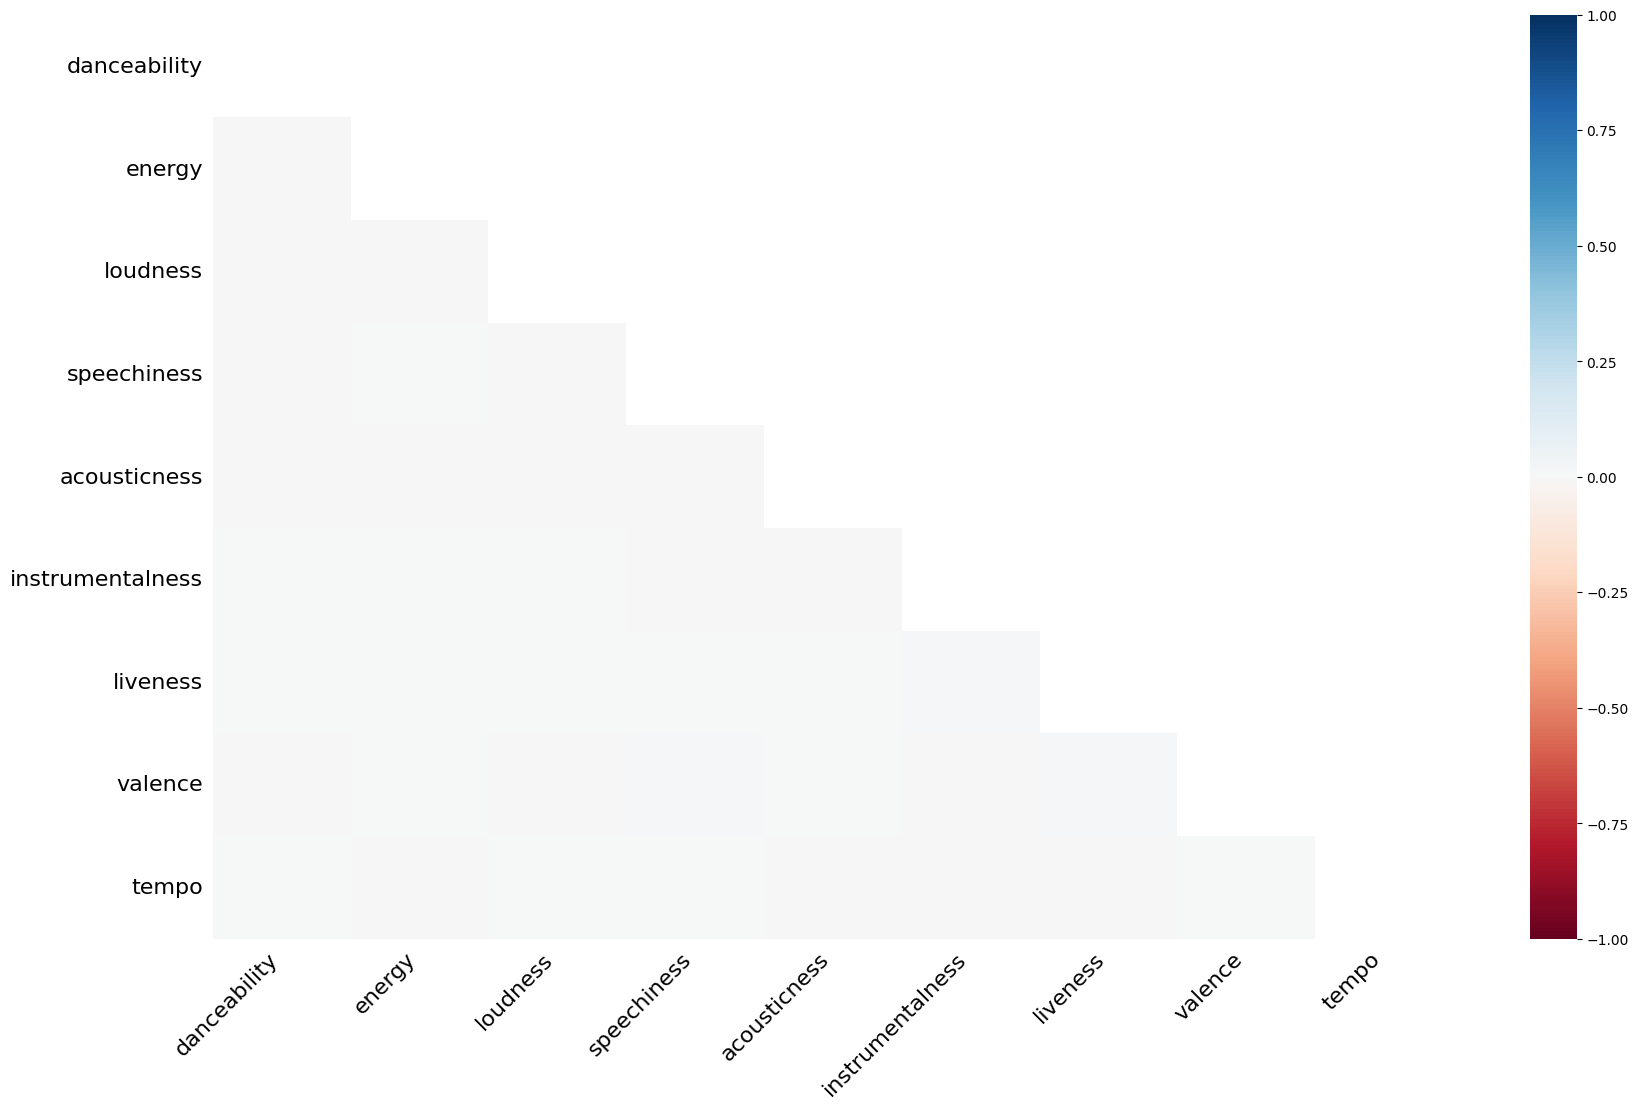

In [ ]:
msno.heatmap(df)

<Axes: >

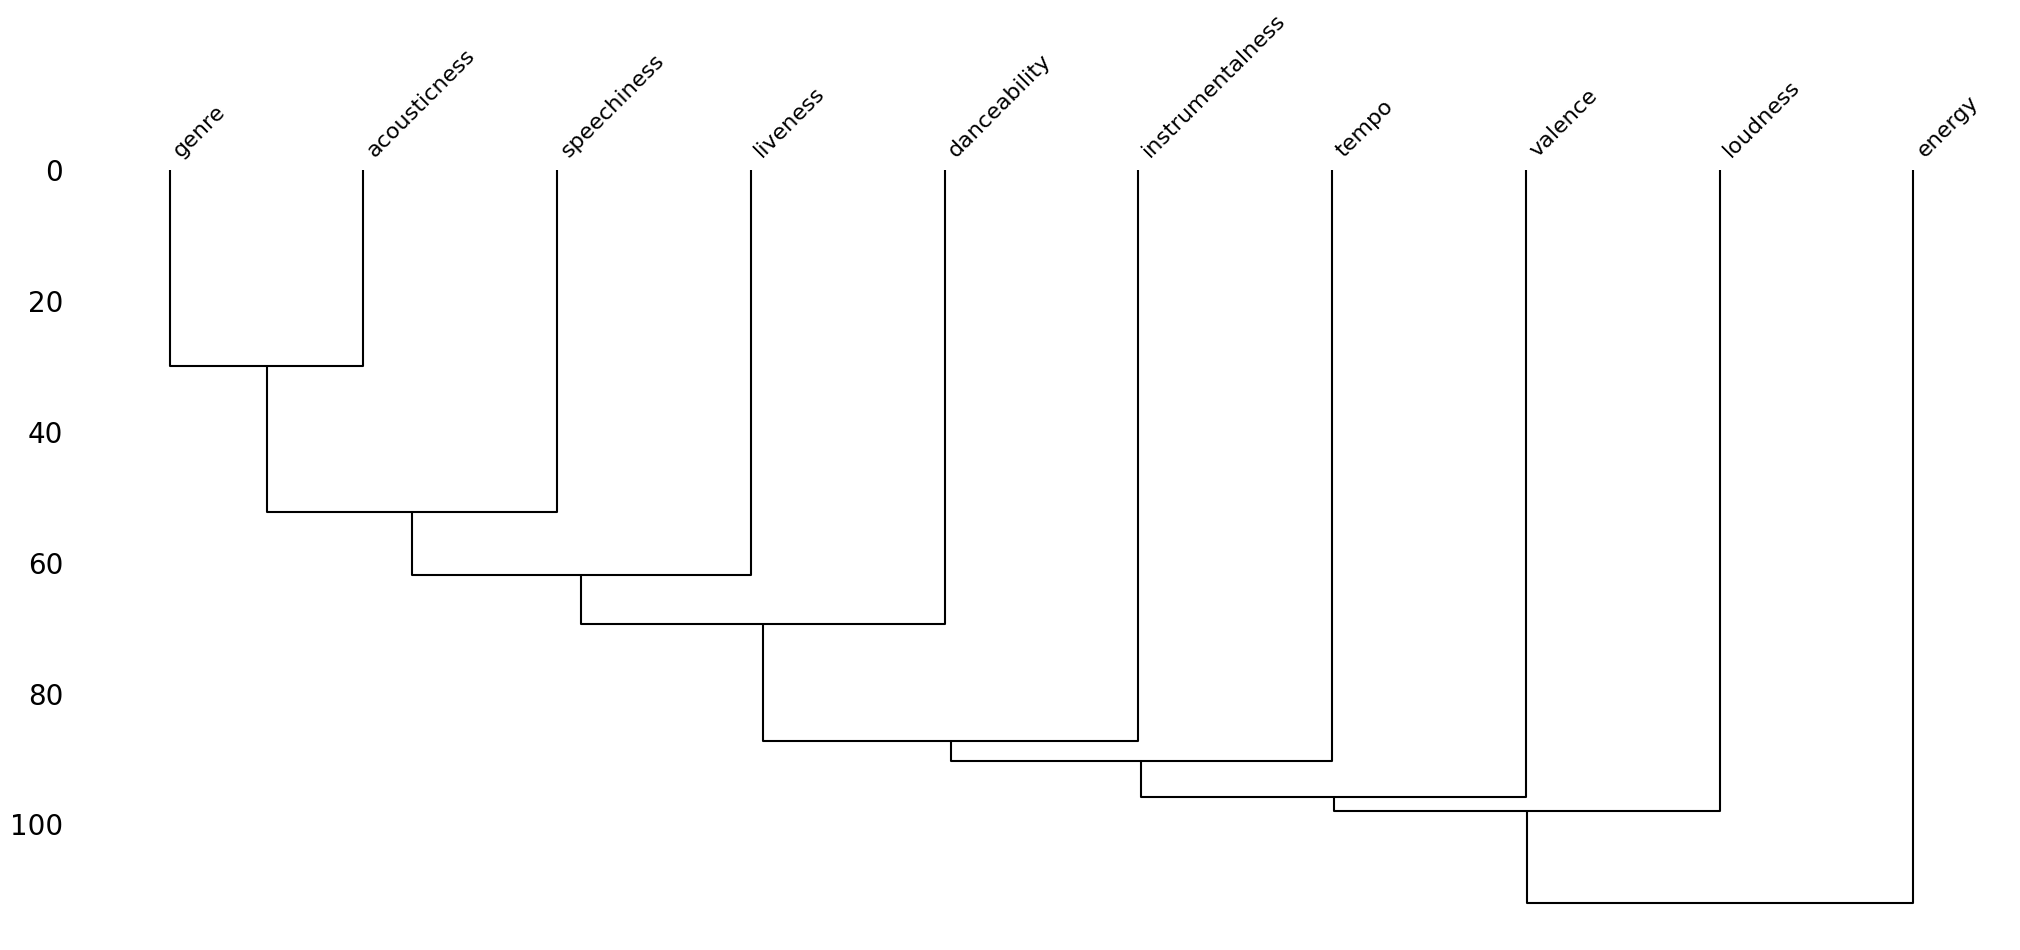

In [ ]:
msno.dendrogram(df)

<Axes: >

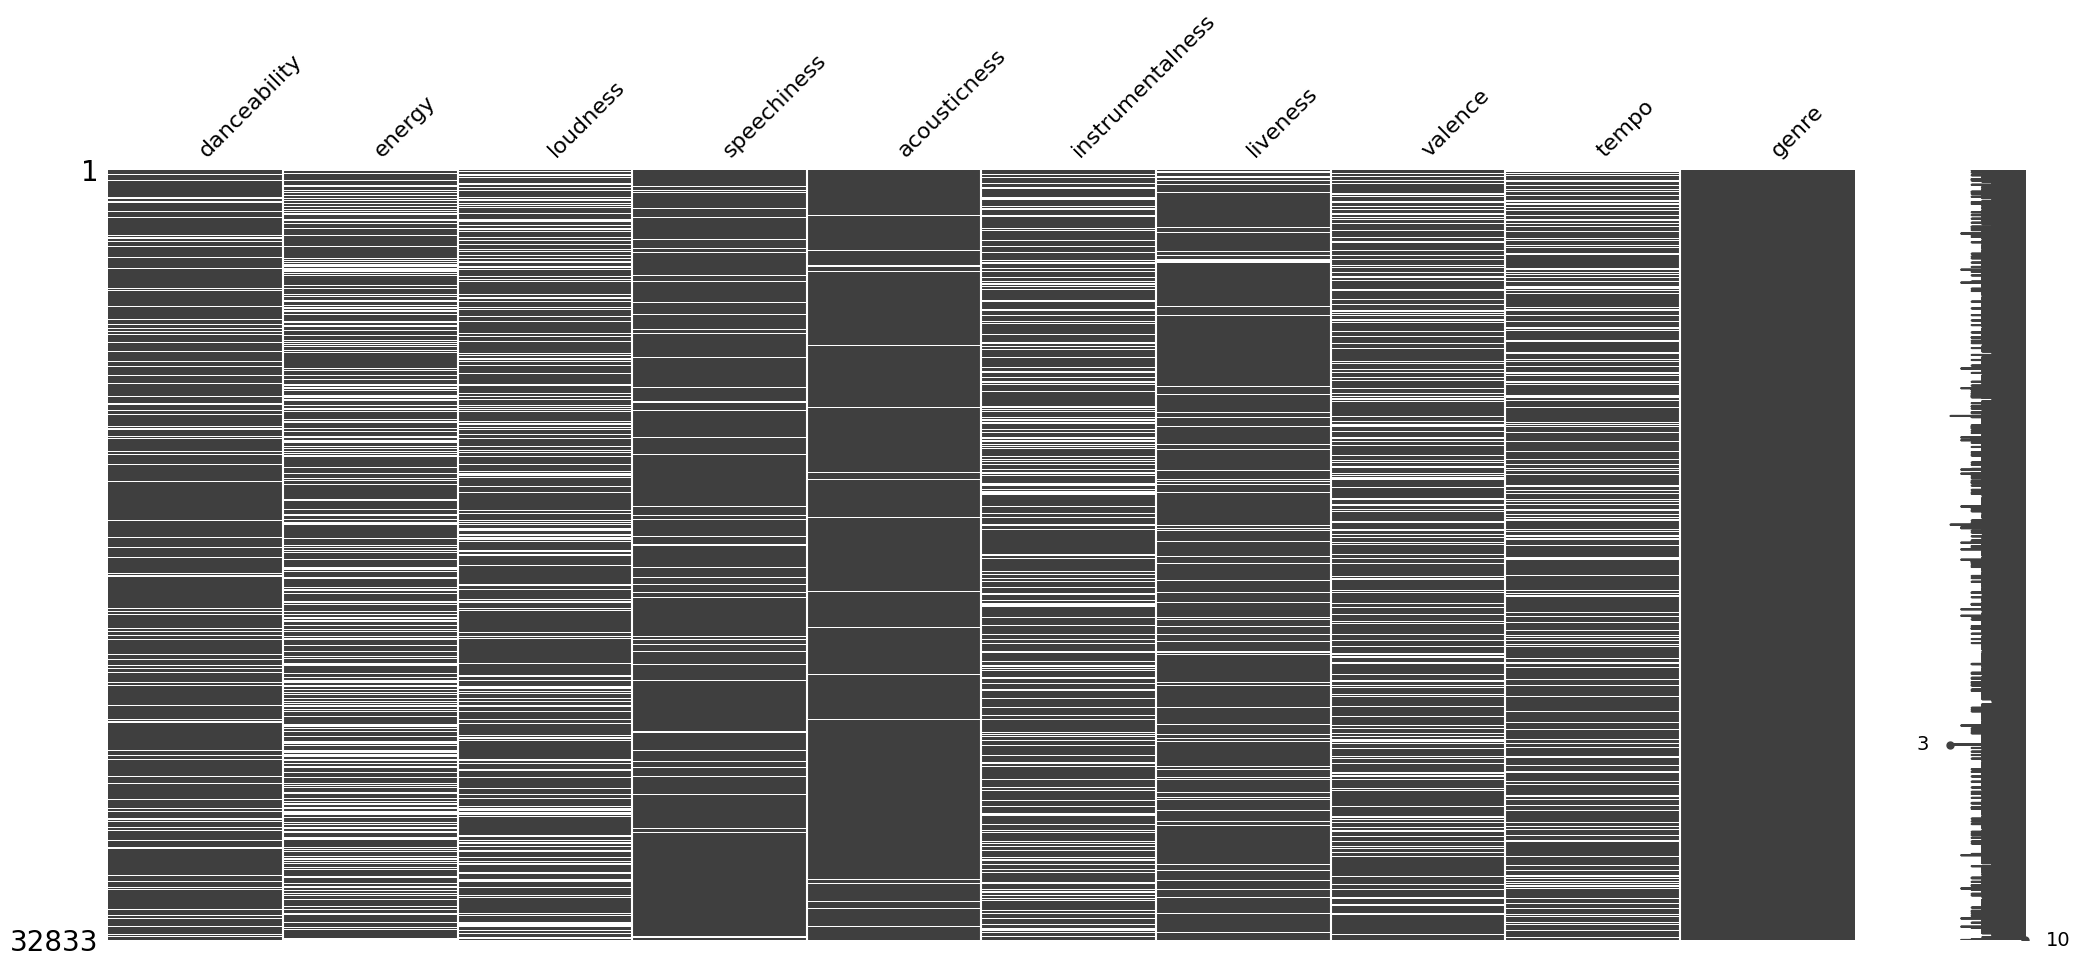

In [ ]:
msno.matrix(df.sort_values('genre'))

<Axes: >

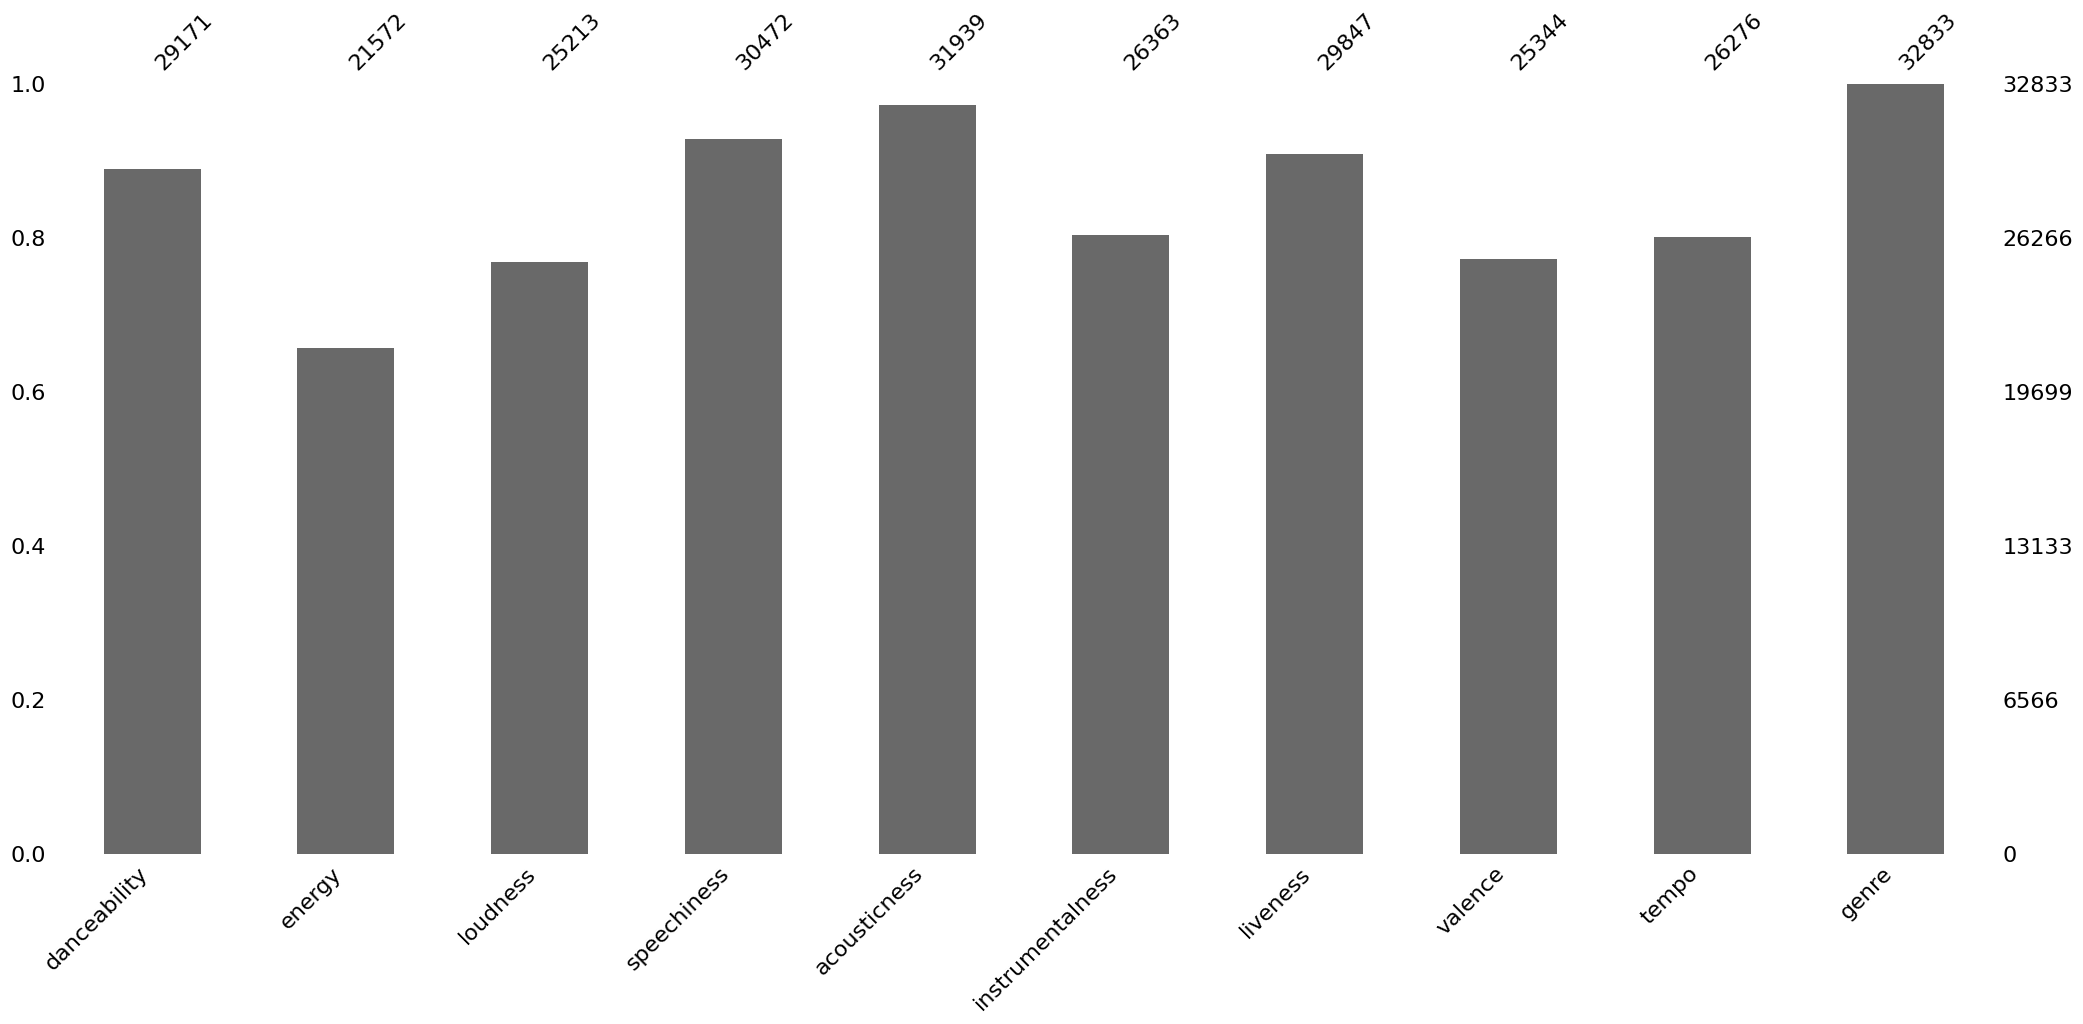

In [ ]:
msno.bar(df)

## Handling the Missing Values

In [ ]:
# Parwise Deletion(only the missing values are deleted)
df_1 = df.copy()
df_1['energy'].mean()

0.6979641560819582

In [ ]:
# Listwise deletion(complete rows which contain the missing values are deleted)
df_1.dropna(subset=['energy'],how='any',inplace=True)
df_1['energy'].isnull().sum()

0

## Dataset Splitting
-Partition the dataset into training and testing sets with an 80:20 ratio.

In [ ]:
from sklearn.impute import KNNImputer
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
df_knn = df.copy(deep=True)
x=df_knn.drop('genre',axis=1)
y= df_knn.genre

In [ ]:
x.head()

,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,0.748,0.916,-2.634,0.0583,0.1020,0.000000,0.0653,0.518,122.036
1,0.726,NaN,-4.969,0.0373,0.0724,NaN,0.3570,0.693,99.972
2,0.675,0.931,-3.432,0.0742,0.0794,NaN,0.1100,0.613,124.008
3,0.718,0.930,-3.778,0.1020,0.0287,0.000009,0.2040,0.277,NaN
4,0.650,0.833,-4.672,0.0359,0.0803,0.000000,0.0833,0.725,123.976


In [ ]:
y.head()

,genre
0,2
1,2
2,2
3,2
4,2


In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

## Feature Scaling
-Standardizing the features using `MinMaxScaler`.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_knn['genre']=scaler.fit_transform(df_knn['genre'].to_numpy().reshape(-1, 1) )

knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")
df_knn['genre'] = knn_imputer.fit_transform(df_knn[['genre']])

## K-Nearset Neighbors Classification

-Creating an instance of the KNN Classification model and training it using the `fit` function.

In [ ]:
#Heandling the missing values
from sklearn.impute import SimpleImputer

# Define an imputer to replace missing values with the mean
imputer = SimpleImputer(strategy='mean')

# Fit the imputer on x_train and y_test and transform the data
x_train_imputed = imputer.fit_transform(x_train)

x_test_imputed = imputer.transform(x_test)

#Fit the model on the imputed data
knn.fit(x_train_imputed, y_train)


KNeighborsClassifier()

In [ ]:
knn_imputer = KNNImputer(n_neighbors=2, weights="uniform")
df_knn['genre'] = knn_imputer.fit_transform(df_knn[['genre']])

-Using the trained model to make predictions for the test set.

In [ ]:
y_pred = knn.predict(x_test_imputed)
y_pred

array([2, 2, 1, ..., 1, 2, 0])

-Assessing the performance of the model by using different classification metrics provided by the `scikit-learn` library.

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.47      0.63      0.54      1193
           1       0.28      0.36      0.32      1017
           2       0.24      0.25      0.25      1115
           3       0.28      0.27      0.27      1067
           4       0.39      0.30      0.33      1166
           5       0.40      0.26      0.32      1009

    accuracy                           0.35      6567
   macro avg       0.34      0.34      0.34      6567
weighted avg       0.35      0.35      0.34      6567

